# Importing libraries

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from tqdm import tqdm

import imageio.v2 as imageio

import netCDF4 as nc
from netCDF4 import num2date, date2num, date2index
import pytz
import datetime

In [2]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
plt.style.use("math.mplstyle")

# Loading dataset

In [ ]:
# load landsat instead here if fourier coefficients for landsat are needed

os.chdir("../salton-sea-final")
cwd = os.getcwd()
df = nc.Dataset(os.path.join(cwd, "salton-sea-full.nc"), "r")
df["crs"]

<class 'netCDF4.Variable'>
int8 crs()
    grid_mapping_name: utm
    _CoordinateAxisTypes: GeoX GeoY
    spatial_ref: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
    epsg_code: 32611
    horizontal_datum_name: WGS84
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of -127 ignored

In [4]:
df.variables.keys()

dict_keys(['LST', 'LST_err', 'QC', 'cloud', 'crs', 'time', 'xdim', 'ydim'])

In [5]:
# Landsat
print(np.diff(df["xdim"][:])[:5])  # should be constant, 30m
print(np.diff(df["ydim"][:])[:5])

[70. 70. 70. 70. 70.]
[-70. -70. -70. -70. -70.]


In [4]:
times = df.variables["time"]
lst = df.variables["LST"]
cloud = df.variables["cloud"]

dates = num2date(times[:], units=times.units)
dates[0].strftime("%Y-%m-%d %H:%M:%S"), dates[-1].strftime("%Y-%m-%d %H:%M:%S")

('2018-07-14 06:43:42', '2025-01-26 20:39:38')

# Data cleaning

In [ ]:
# run to generate clean indices

clean_indices = np.array([i for i in tqdm(range(len(lst))) if not lst[i].mask.all()])
np.save("clean_indices.npy", clean_indices)

  0%|          | 5/1305 [00:05<23:14,  1.07s/it]/var/folders/43/sfdz93_d3h330ysq5n42ylq00000gn/T/ipykernel_44137/225424276.py:3: UserWarning: WARNING: _FillValue not used since it
cannot be safely cast to variable data type
  clean_indices = np.array([i for i in tqdm(range(len(lst))) if not lst[i].mask.all()])
  1%|▏         | 17/1305 [00:17<21:26,  1.00it/s]

In [ ]:
# run to generate orbits

orbits = []

i = 0
while i < len(clean_indices):
    first_index = i
    curr_time = times[clean_indices[i]]
    while i < len(clean_indices) and times[clean_indices[i]] - curr_time <= 3600:
        i += 1
    last_index = i - 1
    orbits.append([first_index, last_index])

orbits = np.array(orbits)
np.save("orbits.npy", orbits)

# Helper functions

In [5]:
orbits = np.load("orbits.npy")
clean_indices = np.load("clean_indices.npy")

In [6]:
def get_image(i):
    first_index, last_index = orbits[i]
    i = first_index
    curr_lst = lst[clean_indices[i]]
    curr_cloud = cloud[clean_indices[i]]
    curr_time = times[clean_indices[i]]

    i += 1
    while i < last_index:
        lst[clean_indices[i]].mask = lst[clean_indices[i]].mask | (curr_lst.mask == 1)
        curr_lst = np.ma.array(
            curr_lst.filled(1) * lst[clean_indices[i]].filled(1),
            mask=curr_lst.mask * lst[clean_indices[i]].mask,
        )

        final_mask = curr_cloud.mask & cloud[clean_indices[i]].mask

        curr_cloud = np.ma.array(
            np.ma.array(
                np.maximum(curr_cloud.filled(0), cloud[clean_indices[i]].filled(0)),
                mask=final_mask,
            ).filled(0),
            mask=final_mask,
        )
        i += 1
    
    return curr_lst, curr_cloud, curr_time

In [7]:
def local_time(time):
    time = num2date(time, units=times.units)
    return datetime.datetime(
        time.year,
        time.month,
        time.day,
        time.hour,
        time.minute,
        time.second,
        tzinfo=pytz.utc,
    ).astimezone(pytz.timezone("America/Los_Angeles"))

In [ ]:
def plot_image(i):
    curr_lst, curr_cloud, curr_time = get_image(i)
    marr = np.ma.filled(curr_lst, np.nan)
    low_percentile = max(np.nanpercentile(marr, 5), 240)
    high_percentile = min(np.nanpercentile(marr, 95), 340)
    a = np.clip(np.ma.copy(curr_lst), low_percentile, high_percentile)
    a.mask[a == high_percentile] = 1.0
    cmap = matplotlib.cm.viridis
    cmap.set_bad("black", 1.0)
    cmap.set_under("gray", 1.0)
    a.mask = (curr_cloud != 1.0) & a.mask
    a[curr_cloud == 1.0] = low_percentile - 1
    plt.axis("off")
    plt.imshow(a, cmap=cmap, vmin=low_percentile, vmax=high_percentile)
    plt.savefig(f"images/lst_{i}.png", bbox_inches="tight", dpi=200)
    plt.close()

In [13]:
plot_image(240)

# Modeling

In [ ]:
df.variables["time"]

<class 'netCDF4.Variable'>
int32 time(time)
    standard_name: time
    axis: T
    calendar: julian
    units: seconds since 2018-05-07 00:00:00+00:00
unlimited dimensions: time
current shape = (1305,)
filling on, default _FillValue of -2147483647 used

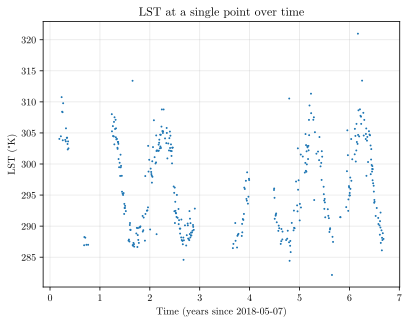

In [ ]:
plt.scatter(times[clean_indices] / 3600 / 24 / 365, lst[clean_indices, 200, 200], s=1)
plt.title("LST at a single point over time")
plt.xlabel("Time (years since 2018-05-07)")
plt.ylabel("LST (°K)")
plt.savefig("images/lst_single_point")
plt.show()

In [11]:
def fit_sine_cosine(times, lst, i, j):
    x = times[clean_indices]
    y = lst[clean_indices, i, j]
    y = y.filled(np.nan)
    mask = np.isnan(y)
    x = x[~mask]
    y = y[~mask]
    A = np.vstack(
        [
            np.ones_like(x),
            np.sin(2 * np.pi * x / 31536000),
            np.cos(2 * np.pi * x / 31536000),
            np.sin(2 * np.pi * x / 86400),
            np.cos(2 * np.pi * x / 86400),
        ]
    ).T
    return np.linalg.lstsq(A, y, rcond=None)[0]

In [12]:
def plot_fit(i, j):
    x = times[clean_indices]
    y = lst[clean_indices, i, j]
    y = y.filled(np.nan)
    mask = np.isnan(y)
    x = x[~mask]
    y = y[~mask]
    coef = fit_sine_cosine(times, lst, i, j)
    plt.scatter(x, y, s=1)
    t = np.linspace(x[0], x[-1], 10000)
    plt.plot(
        t,
        coef[0] + coef[1] * np.sin(2 * np.pi * t / 31536000) + coef[2] * np.cos(2 * np.pi * t / 31536000) + coef[3] * np.sin(2 * np.pi * t / 86400) + coef[4] * np.cos(2 * np.pi * t / 86400),
        color="red",
    )
    plt.show()

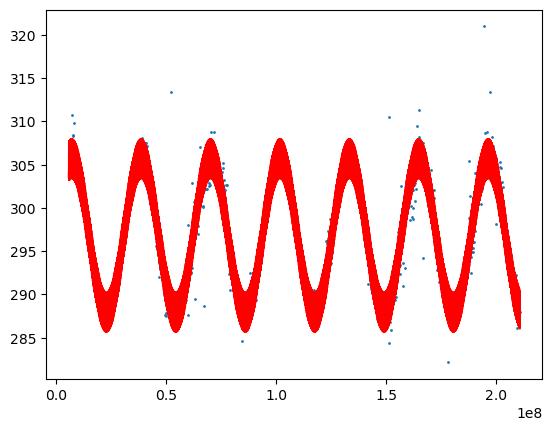

In [ ]:
plot_fit(200, 200)

In [31]:
def compute_coeff(i, nc_file, clean_indices):
    ds = nc.Dataset(nc_file, "r")
    lst = ds.variables["LST"]
    times = ds.variables["time"]

    tmp = np.zeros((lst.shape[2], 5))
    for j in range(lst.shape[2]):
        tmp[j] = fit_sine_cosine(times, lst, i, j)

    ds.close()
    return tmp

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

nc_file = os.path.join(cwd, "salton-sea-full.nc")
results = Parallel(n_jobs=-1, backend="multiprocessing", mmap_mode="r", verbose=5)(
    delayed(compute_coeff)(i, nc_file, clean_indices) for i in tqdm(range(lst.shape[1]))
)


  2%|█▊                                                                                                            | 23/1423 [17:11<17:26:07, 44.83s/it]
[Parallel(n_jobs=-1)]: Using backend MultiprocessingBackend with 12 concurrent workers.




In [ ]:
results = np.array(results)
np.save("results.npy", results)

In [13]:
results = np.load("results.npy")

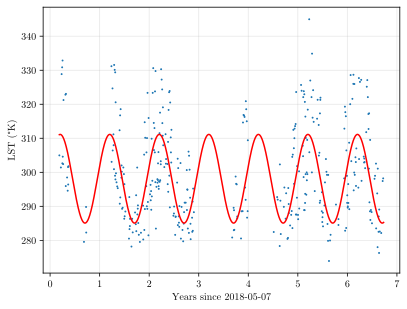

In [ ]:
coefs = results[200, 950, :]
t = np.linspace(times[clean_indices][0], times[clean_indices][-1], 10000)

plt.plot(
    t / 3600 / 24 / 365,
    coefs[0] + coefs[1] * np.sin(2 * np.pi * t / 31536000) + coefs[2] * np.cos(2 * np.pi * t / 31536000),
    color="red",
)
plt.scatter(times[clean_indices] / 3600 / 24 / 365, lst[clean_indices, 200, 950], s=1)
plt.xlabel("Years since 2018-05-07")
plt.ylabel("LST (°K)")
plt.savefig("images/annual_cycle_single_point")
plt.show()

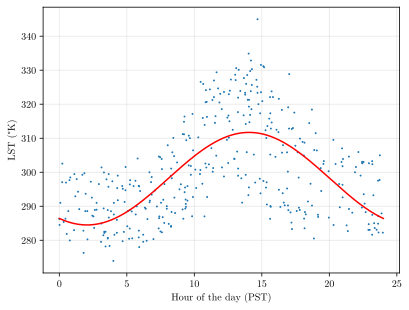

In [ ]:
def plot_diurnal_cycle(i, j):
    coefs = results[i, j, :]
    t_hours = np.linspace(0, 24, 10000)

    start_time = times[clean_indices][0]
    start_local = local_time(start_time)
    seconds_to_midnight = (
        (24 - start_local.hour) * 3600 - start_local.minute * 60 - start_local.second
    )

    t_secs_model = t_hours * 3600 + start_time + seconds_to_midnight

    plt.plot(
        t_hours,
        coefs[0]
        + coefs[3] * np.sin(2 * np.pi * t_secs_model / 86400)
        + coefs[4] * np.cos(2 * np.pi * t_secs_model / 86400),
        color="red",
    )

    local_times = np.array([local_time(t) for t in times[clean_indices]])
    hours = np.array(
        [lt.hour + lt.minute / 60 + lt.second / 3600 for lt in local_times]
    )
    plt.scatter(hours, lst[clean_indices, i, j], s=1)


plot_diurnal_cycle(200, 950)
plt.xlabel("Hour of the day (PST)")
plt.ylabel("LST (°K)")
plt.savefig("images/diurnal_cycle_single_point")
plt.show()

In [ ]:
start_time = times[clean_indices][0]
start_datetime = num2date(start_time, units=times.units)
start_local = local_time(start_time)

print(f"Start time (UTC): {start_datetime}")
print(f"Start time (Local): {start_local}")
print(f"Start hour (UTC): {start_datetime.hour}")
print(f"Start hour (Local): {start_local.hour}")
print(f"Seconds since epoch: {start_time}")

Start time (UTC): 2018-07-14 06:43:42
Start time (Local): 2018-07-13 23:43:42-07:00
Start hour (UTC): 6
Start hour (Local): 23
Seconds since epoch: 5899422


In [ ]:
amplitude = np.sqrt(results[:, :, 1] ** 2 + results[:, :, 2] ** 2)
plt.imshow(np.clip(amplitude, np.percentile(amplitude, 5), np.percentile(amplitude, 95)), cmap="coolwarm")
plt.colorbar()
plt.show()

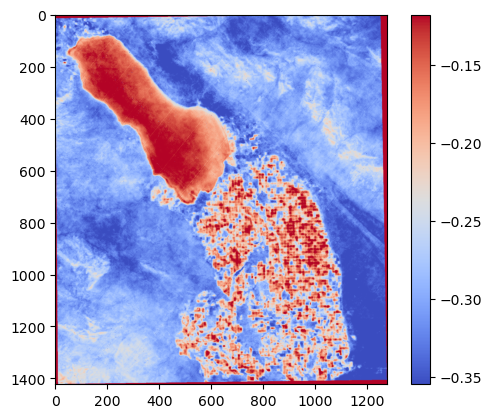

In [16]:
phase = np.arctan2(-results[:, :, 2], results[:, :, 1])
plt.imshow(
    np.clip(phase, np.percentile(phase, 5), np.percentile(phase, 95)),
    cmap="coolwarm",
)
plt.colorbar()
plt.show()

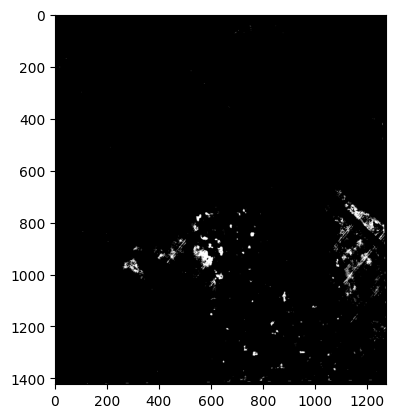

In [ ]:
plt.imshow(amplitude > np.percentile(amplitude, 99), cmap="gray")

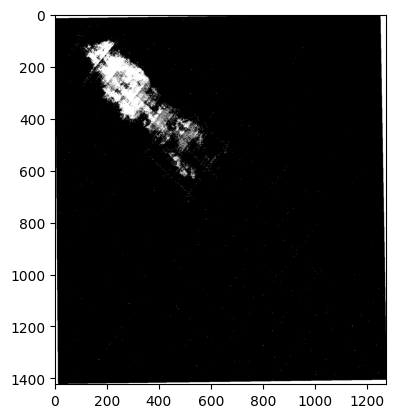

In [49]:
plt.imshow(amplitude < np.percentile(amplitude, 5), cmap="gray")

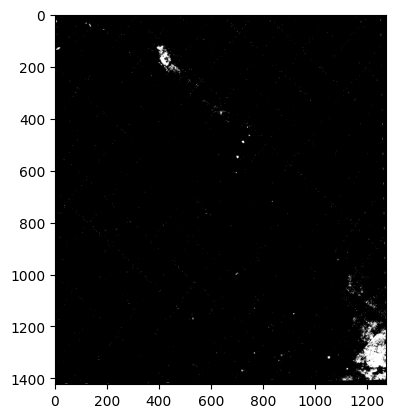

In [52]:
plt.imshow(phase > np.percentile(phase, 99), cmap="gray")

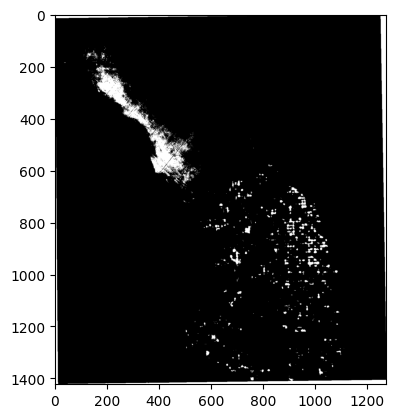

In [53]:
plt.imshow(phase < np.percentile(phase, 5), cmap="gray")

In [53]:
def plot_predicted(t):
    curr_time = times[t]

    sin_annual = np.sin(2 * np.pi * t / 31536000)
    cos_annual = np.cos(2 * np.pi * t / 31536000)
    sin_daily = np.sin(2 * np.pi * t / 86400)
    cos_daily = np.cos(2 * np.pi * t / 86400)

    predicted_lst = (
        results[:, :, 0]
        + results[:, :, 1] * sin_annual
        + results[:, :, 2] * cos_annual
        + results[:, :, 3] * sin_daily
        + results[:, :, 4] * cos_daily
    )

    plt.axis("off")
    plt.imshow(np.clip(predicted_lst, np.percentile(predicted_lst, 5), np.percentile(predicted_lst, 95)), cmap="coolwarm")
    plt.colorbar()
    plt.title(f"Time: {local_time(curr_time).strftime('%Y-%m-%d %H:%M:%S')}")
    plt.savefig(f"predicted_images/predicted_lst_{t}.png", bbox_inches="tight")
    plt.close()

In [54]:
plot_predicted(562)

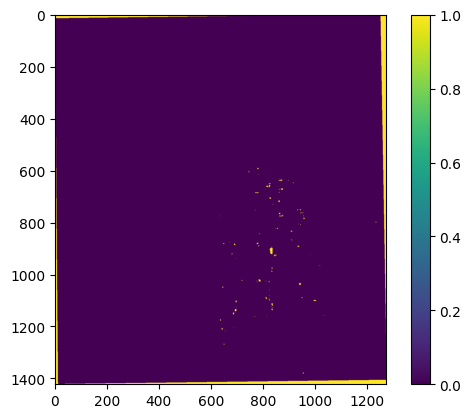

In [263]:
mask = lst[301].mask
plt.imshow(mask)
plt.colorbar()

plt.show()

In [56]:
def plot_residual(i):
    curr_lst, curr_cloud, curr_time = get_image(i)
    predicted_lst = (
        results[:, :, 0]
        + results[:, :, 1] * np.sin(2 * np.pi * times[clean_indices][i] / 31536000)
        + results[:, :, 2] * np.cos(2 * np.pi * times[clean_indices][i] / 31536000)
        + results[:, :, 3] * np.sin(2 * np.pi * times[clean_indices][i] / 86400)
        + results[:, :, 4] * np.cos(2 * np.pi * times[clean_indices][i] / 86400)
    )

    residual = curr_lst - predicted_lst
    residual = np.ma.array(residual, mask=curr_lst.mask)
    plt.axis("off")
    plt.imshow(residual, cmap="coolwarm")
    plt.colorbar()
    plt.title(f"Time: {local_time(curr_time).strftime('%Y-%m-%d %H:%M:%S')}")
    plt.savefig(f"residual_images/residual_{i}.png", bbox_inches="tight")
    plt.close()

In [58]:
plot_residual(301)